# 02 Data Synthesis and Merging

This notebook merges the cleaned indicators into a single LSOA-level dataset for England and Wales.

In [18]:
import pandas as pd


percentages_file = r'../data/percentages.csv'
total_file = r'../data/test.csv'

# Load the CSV files into pandas DataFrames
percentages_df = pd.read_csv(percentages_file)
total_df = pd.read_csv(total_file)

#percentages_df['LSOA21CD'] = percentages_df['LSOA21CD'].str.split(':').str[0].str.strip()
# Merge the two DataFrames based on the common variable 'LSOACD21'
# Use an inner join to keep only the rows in 'percentages' that have matching rows in 'Total'
combined_df = pd.merge(percentages_df, total_df, on='LSOA21CD', how='left')

# Display the first few rows of the combined DataFrame to verify the merge
print(combined_df.head())
df = combined_df


                      LSOA21CD  %Conveniance  %Discounter  %Premium  \
0  E01011954 : Hartlepool 001A      6.774535     6.986124  1.628715   
1  E01011969 : Hartlepool 001B      6.447331     6.698201  2.101732   
2  E01011970 : Hartlepool 001C      6.546606     6.166846  2.186891   
3  E01011971 : Hartlepool 001D      6.677455     6.083179  2.474948   
4  E01033465 : Hartlepool 001F      6.935692     5.548272  2.106664   

      %Value  %Online Often  %Online Sometimes  %Online Rarely  %Online Never  \
0  84.610626      18.355779          53.566159       21.745225       6.332837   
1  84.752736      12.903337          54.770531       26.295369       6.030763   
2  85.099658      12.201860          51.157502       28.270144       8.370494   
3  84.764418      11.969758          52.568514       27.101725       8.360003   
4  85.409372      12.114308          52.440362       27.251753       8.193578   

   %Less than £50  ...  \
0       21.199064  ...   
1       22.727646  ...   
2       

In [42]:
hp_file = r"../data/houseprice.csv"
lu_file = r"../data/LSOA_(2011)_to_LSOA_(2021)_to_Local_Authority_District_(2022)_Lookup_for_England_and_Wales.csv"
hp = pd.read_csv(hp_file)
lu = pd.read_csv(lu_file)


In [44]:
lu


,LSOA11CD,LSOA11NM,LSOA21CD,LSOA21NM,LAD22CD,LAD22NM,LAD22NMW,ObjectId
0,E01000155,Barnet 030D,E01033916,Barnet 042B,E09000003,Barnet,NaN,1
1,E01000305,Barnet 036B,E01000305,Barnet 036B,E09000003,Barnet,NaN,2
2,E01000001,City of London 001A,E01000001,City of London 001A,E09000001,City of London,NaN,3
3,E01000156,Barnet 022A,E01000156,Barnet 022A,E09000003,Barnet,NaN,4
4,E01000157,Barnet 022B,E01000157,Barnet 022B,E09000003,Barnet,NaN,5
...,...,...,...,...,...,...,...,...
34748,W01001855,Cardiff 042A,W01001855,Cardiff 042A,W06000015,Cardiff,Caerdydd,34749
34749,W01001856,Cardiff 042B,W01001856,Cardiff 042B,W06000015,Cardiff,Caerdydd,34750
34750,W01001857,Cardiff 042C,W01001857,Cardiff 042C,W06000015,Cardiff,Caerdydd,34751
34751,W01001858,Cardiff 034A,W01001858,Cardiff 034A,W06000015,Cardiff,Caerdydd,34752


In [47]:
# Merge your dataset with the lookup table
df_merged = pd.merge(hp, lu, how='left', left_on='LSOA11CD', right_on='LSOA11CD')

# After merging, df_merged should now contain a column with the corresponding 2021 LSOA codes
df_merged


,LSOA11CD,Year ending Mar 2023,LSOA11NM,LSOA21CD,LSOA21NM,LAD22CD,LAD22NM,LAD22NMW,ObjectId
0,E01011949,"106,500",Hartlepool 009A,E01011949,Hartlepool 009A,E06000001,Hartlepool,NaN,11244
1,E01011950,"43,500",Hartlepool 008A,E01011950,Hartlepool 008A,E06000001,Hartlepool,NaN,11245
2,E01011951,"66,000",Hartlepool 007A,E01011951,Hartlepool 007A,E06000001,Hartlepool,NaN,11246
3,E01011952,"60,000",Hartlepool 002A,E01011952,Hartlepool 002A,E06000001,Hartlepool,NaN,11247
4,E01011953,"92,500",Hartlepool 002B,E01011953,Hartlepool 002B,E06000001,Hartlepool,NaN,11651
...,...,...,...,...,...,...,...,...,...
34748,W01001320,"149,500",Merthyr Tydfil 007C,W01001320,Merthyr Tydfil 007C,W06000024,Merthyr Tydfil,Merthyr Tudful,34354
34749,W01001321,"120,000",Merthyr Tydfil 007D,W01001321,Merthyr Tydfil 007D,W06000024,Merthyr Tydfil,Merthyr Tudful,34355
34750,W01001322,"136,000",Merthyr Tydfil 007E,W01001322,Merthyr Tydfil 007E,W06000024,Merthyr Tydfil,Merthyr Tudful,34356
34751,W01001324,"145,000",Merthyr Tydfil 003E,W01001324,Merthyr Tydfil 003E,W06000024,Merthyr Tydfil,Merthyr Tudful,34357


In [5]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from clustergram import Clustergram

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import FancyArrow


ModuleNotFoundError: No module named 'matplotlib_scalebar'

In [29]:
range_scaled_df


,LSOA21CD,Aged_16-24,Aged_25-34,Aged_35-49,Age_50-64,Aged_65+,Female,Never_married/partnership,Divorced_or_Widowed,1 person in household,...,PT_supermarket_pct_15,PT_supermarket_pct_30,No cars or vans in household,High Internet Use,Medium Internet Use,Low Internet Use,int_acc_yes,Online Often,Online Never,Online_Sometimes/Rarely
0,E01011954,0.802059,0.570151,0.435901,0.433736,0.365390,0.223168,0.676042,0.415880,0.577109,...,0.000000,0.054954,0.752695,0,1,0,0.738600,0.471669,0.557596,0.420564
1,E01011969,0.724809,0.415943,0.348473,0.536639,0.620089,0.181448,0.435044,0.424463,0.553615,...,0.000000,0.043921,0.585301,0,0,1,0.857321,0.261232,0.531091,0.699145
2,E01011970,0.716939,0.502117,0.342667,0.614510,0.593945,0.197302,0.444519,0.375859,0.539171,...,0.000000,0.010962,0.511332,1,0,0,0.850744,0.227677,0.727840,0.608028
3,E01011971,0.842386,0.465317,0.529772,0.648619,0.333427,0.207767,0.556672,0.301670,0.454934,...,0.090695,0.021996,0.405194,1,0,0,0.880958,0.216137,0.726997,0.620878
4,E01033465,0.778503,0.517611,0.710144,0.346817,0.289945,0.175775,0.580024,0.301670,0.463810,...,0.090695,0.032958,0.461155,1,0,0,0.867180,0.223351,0.713577,0.622047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34623,W01001300,0.812247,0.546249,0.421289,0.370327,0.399192,0.227734,0.670845,0.401582,0.531763,...,0.000000,0.000000,0.798249,0,0,1,0.789502,0.480174,0.580897,0.400101
34624,W01001301,0.793190,0.574285,0.488632,0.366929,0.344262,0.218677,0.699038,0.447358,0.566212,...,0.000000,0.032958,0.811438,0,0,1,0.755447,0.480893,0.541337,0.416615
34625,W01001308,0.819760,0.537024,0.430054,0.444713,0.340671,0.297143,0.734961,0.421602,0.547896,...,0.181979,0.032958,0.779343,0,0,1,0.849007,0.548677,0.496773,0.352713
34626,W01001309,0.795472,0.548508,0.479831,0.340219,0.413894,0.199360,0.702892,0.407300,0.537700,...,0.000000,0.032958,0.722125,0,1,0,0.806607,0.476829,0.509666,0.435753


In [7]:
file_path = r"../data/all_done.csv"

# Reading the CSV file
range_scaled_df = pd.read_csv(file_path)

combined_df = range_scaled_df


In [31]:
combined_df


,LSOA21CD,Aged_16-24,Aged_25-34,Aged_35-49,Age_50-64,Aged_65+,Female,Never_married/partnership,Divorced_or_Widowed,1 person in household,...,PT_supermarket_pct_15,PT_supermarket_pct_30,No cars or vans in household,High Internet Use,Medium Internet Use,Low Internet Use,int_acc_yes,Online Often,Online Never,Online_Sometimes/Rarely
0,E01011954,0.802059,0.570151,0.435901,0.433736,0.365390,0.223168,0.676042,0.415880,0.577109,...,0.000000,0.054954,0.752695,0,1,0,0.738600,0.471669,0.557596,0.420564
1,E01011969,0.724809,0.415943,0.348473,0.536639,0.620089,0.181448,0.435044,0.424463,0.553615,...,0.000000,0.043921,0.585301,0,0,1,0.857321,0.261232,0.531091,0.699145
2,E01011970,0.716939,0.502117,0.342667,0.614510,0.593945,0.197302,0.444519,0.375859,0.539171,...,0.000000,0.010962,0.511332,1,0,0,0.850744,0.227677,0.727840,0.608028
3,E01011971,0.842386,0.465317,0.529772,0.648619,0.333427,0.207767,0.556672,0.301670,0.454934,...,0.090695,0.021996,0.405194,1,0,0,0.880958,0.216137,0.726997,0.620878
4,E01033465,0.778503,0.517611,0.710144,0.346817,0.289945,0.175775,0.580024,0.301670,0.463810,...,0.090695,0.032958,0.461155,1,0,0,0.867180,0.223351,0.713577,0.622047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34623,W01001300,0.812247,0.546249,0.421289,0.370327,0.399192,0.227734,0.670845,0.401582,0.531763,...,0.000000,0.000000,0.798249,0,0,1,0.789502,0.480174,0.580897,0.400101
34624,W01001301,0.793190,0.574285,0.488632,0.366929,0.344262,0.218677,0.699038,0.447358,0.566212,...,0.000000,0.032958,0.811438,0,0,1,0.755447,0.480893,0.541337,0.416615
34625,W01001308,0.819760,0.537024,0.430054,0.444713,0.340671,0.297143,0.734961,0.421602,0.547896,...,0.181979,0.032958,0.779343,0,0,1,0.849007,0.548677,0.496773,0.352713
34626,W01001309,0.795472,0.548508,0.479831,0.340219,0.413894,0.199360,0.702892,0.407300,0.537700,...,0.000000,0.032958,0.722125,0,1,0,0.806607,0.476829,0.509666,0.435753


In [15]:
import pandas as pd

file_path = r"../data/DF_edit_19_12.csv"

range_scaled_df = pd.read_csv(file_path)

final_df = range_scaled_df



In [18]:
# Create the new column 'Urban Setting' based on the condition
#final_df['Urban Setting'] = (final_df['urban_rural_indicator'] > 0).astype(int)

# Remove the old column 'urban_rural_indicator'
#final_df = final_df.drop(columns=['urban_rural_indicator'])

# Display the first few rows of the updated DataFrame
final_df


,LSOAXXCD,nOA21,LSOA11CD,LSOA21CD,CHG21,online_retail_engagement,low_PT_supermarket_access,high_PT_supermarket_access,low_PT_sub_bua_access,high_PT_sub_bua_access,...,people_2_holidays,have_pets,Yes_Insurance,yes_investments,people_payoff_creditcard_always,int_acc_yes,Under_20K,income_20_to_50k,income_50kplus,Urban Setting
0,X0000001E,1,E01031349,E01031349,U,0,0,0,1,0,...,0.501865,0.535697,0.803361,0.586156,0.540704,0.830189,0.550485,0.619387,0.599179,1
1,X0000002E,1,E01031350,E01031350,U,-1,0,0,1,0,...,0.413884,0.566837,0.633310,0.384840,0.494809,0.799128,0.644389,0.544570,0.520562,1
2,X0000003E,1,E01031351,E01031351,U,0,0,1,1,0,...,0.559519,0.530087,0.813433,0.565336,0.543878,0.846841,0.555250,0.597626,0.607318,1
3,X0000004E,1,E01031352,E01031352,U,-1,0,1,1,0,...,0.550031,0.600163,0.831049,0.658184,0.560301,0.820942,0.467400,0.717763,0.632944,1
4,X0000005E,1,E01031370,E01031370,U,-1,0,1,1,0,...,0.497295,0.490912,0.791284,0.420409,0.470213,0.860838,0.637486,0.540004,0.534757,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35791,X0034629E,1,E01013336,E01013336,U,0,0,1,1,0,...,0.549003,0.526539,0.779269,0.481215,0.480039,0.785259,0.618742,0.599430,0.519446,1
35792,X0034630E,1,E01013337,E01013337,U,0,0,1,1,0,...,0.610551,0.634872,0.769161,0.587884,0.547007,0.799870,0.535223,0.603378,0.627394,1
35793,X0034631E,1,E01013338,E01013338,U,0,0,0,1,0,...,0.699643,0.624451,0.713718,0.497286,0.527039,0.812890,0.567509,0.633121,0.568553,1
35794,X0034632E,1,E01013339,E01013339,U,0,0,0,1,0,...,0.568060,0.578009,0.835768,0.584372,0.548190,0.887799,0.545351,0.611978,0.610123,1


In [19]:
file_path = r"../data/DF_edit_19_12(changed_ruc).csv"
final_df.to_csv(file_path, index=False)


In [7]:
import pandas as pd

# Calculate the correlation matrix for the combined dataframe
correlation_matrix = combined_df.iloc[:, 5:].corr()


# Display the correlation matrix
print(correlation_matrix)

# Filter correlations that are above the threshold (e.g., 0.75)
threshold = 0.75
high_correlation_pairs = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix != 1.0)]

# Display pairs of variables with high correlations
print(high_correlation_pairs)


                                 online_retail_engagement  \
online_retail_engagement                         1.000000   
low_PT_supermarket_access                        0.123429   
medium_PT_supermarket_access                    -0.002863   
high_PT_supermarket_access                      -0.089016   
low_PT_sub_bua_access                            0.049590   
...                                                   ...   
people_payoff_creditcard_always                  0.408768   
int_acc_yes                                      0.308039   
Under_20K                                       -0.397502   
income_20_to_50k                                 0.076747   
income_50kplus                                   0.420483   

                                 low_PT_supermarket_access  \
online_retail_engagement                          0.123429   
low_PT_supermarket_access                         1.000000   
medium_PT_supermarket_access                     -0.305780   
high_PT_supermarket

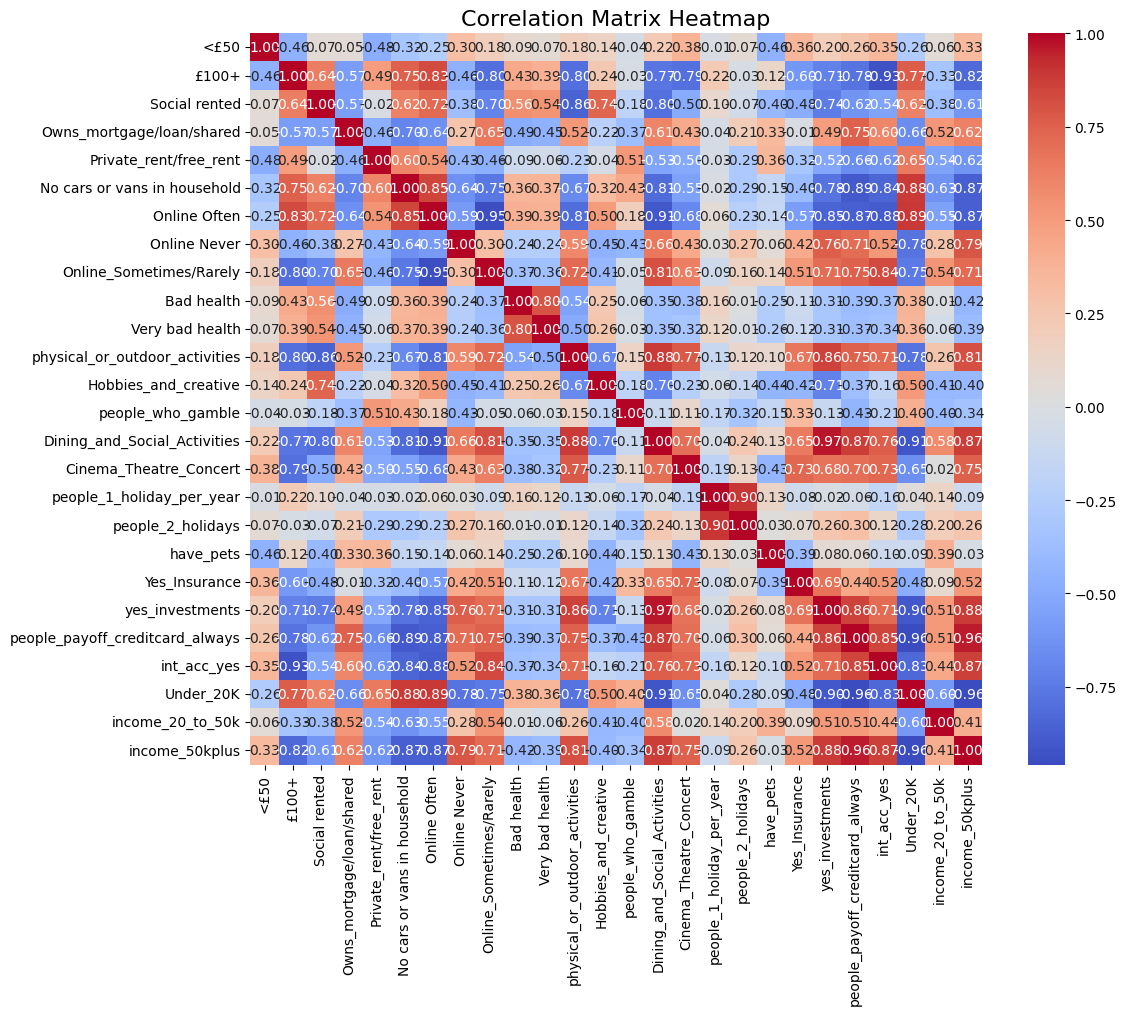

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = combined_df.iloc[:, 45:].corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)

# Add a title
plt.title("Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()


In [9]:
high_correlation_count = high_correlation_pairs.count().sum() // 2  # Divide by 2 to avoid double-counting

# Display the number of highly correlated pairs
print(f"Number of highly correlated pairs: {high_correlation_count}")


Number of highly correlated pairs: 100


In [11]:
import pandas as pd

# Assuming the first column is the one you want to ignore (e.g., 'LSOA21CD')
# Exclude the first column from the correlation calculation
correlation_matrix = combined_df.iloc[:, 5:].corr()

# Filter correlations that are above the threshold (e.g., 0.75)
threshold = 0.8
high_correlation_pairs = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix != 1.0)]

# Extract the pairs of variables that are highly correlated
high_corr_pairs = high_correlation_pairs.stack().reset_index()
high_corr_pairs.columns = ['Variable1', 'Variable2', 'Correlation']



high_corr_pairs = high_corr_pairs.sort_values(by="Correlation", key=lambda x: x.abs(), ascending=False)

high_corr_pairs.head(60)


,Variable1,Variable2,Correlation
2,medium_car_access_supermarket,high_car_access_supermarket,-0.990677
3,high_car_access_supermarket,medium_car_access_supermarket,-0.990677
5,Aged_65+,Economically inactive: Retired,0.985984
15,Economically inactive: Retired,Aged_65+,0.985984
71,Dining_and_Social_Activities,yes_investments,0.966399
80,yes_investments,Dining_and_Social_Activities,0.966399
14,Students,Aged_16-24,0.963832
4,Aged_16-24,Students,0.963832
107,Under_20K,income_50kplus,-0.958543
117,income_50kplus,Under_20K,-0.958543


In [12]:
import pandas as pd

# Assuming the first column is the one you want to ignore (e.g., 'LSOA21CD')
# Exclude the first column from the correlation calculation
correlation_matrix = combined_df.iloc[:, 5:].corr()

# Filter correlations that are above the threshold (e.g., 0.75)
threshold = 0.8
high_correlation_pairs = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix != 1.0)]

# Extract the pairs of variables that are highly correlated
high_corr_pairs = high_correlation_pairs.stack().reset_index()
high_corr_pairs.columns = ['Variable1', 'Variable2', 'Correlation']

# Sort the pairs by correlation in descending order
high_corr_pairs_sorted = high_corr_pairs.sort_values(by='Correlation', ascending=False)

# Display the sorted highly correlated pairs
print("Highly correlated pairs:")
print(high_corr_pairs_sorted)

# Identify the most problematic variables (those that appear most frequently in highly correlated pairs)
problematic_variables = pd.concat([high_corr_pairs_sorted['Variable1'], high_corr_pairs_sorted['Variable2']])
problematic_variable_counts = problematic_variables.value_counts()

# Display the most problematic variables (those that appear most frequently)
print("\nVariables that appear most frequently in highly correlated pairs:")
print(problematic_variable_counts)

# Optionally, you can set a threshold for the most problematic variables
# e.g., variables that appear more than 5 times in the highly correlated pairs
threshold_count = 0
most_problematic = problematic_variable_counts[problematic_variable_counts > threshold_count]

print(f"\nMost problematic variables (appearing more than {threshold_count} times):")
most_problematic.head(60)


Highly correlated pairs:
                           Variable1                       Variable2  \
15    Economically inactive: Retired                        Aged_65+   
5                           Aged_65+  Economically inactive: Retired   
80                   yes_investments    Dining_and_Social_Activities   
71      Dining_and_Social_Activities                 yes_investments   
4                         Aged_16-24                        Students   
..                               ...                             ...   
90   people_payoff_creditcard_always                       Under_20K   
107                        Under_20K                  income_50kplus   
117                   income_50kplus                       Under_20K   
3        high_car_access_supermarket   medium_car_access_supermarket   
2      medium_car_access_supermarket     high_car_access_supermarket   

     Correlation  
15      0.985984  
5       0.985984  
80      0.966399  
71      0.966399  
4       0.96383

Online Often                                          22
income_50kplus                                        20
int_acc_yes                                           16
Under_20K                                             16
Dining_and_Social_Activities                          16
people_payoff_creditcard_always                       16
Discounter                                            14
No cars or vans in household                          14
physical_or_outdoor_activities                        12
yes_investments                                       12
No/Level_1_Qualification                               8
Managerial/administritive/proffesional_occupations     8
£100+                                                  8
Routine_Occupations                                    6
Level 4 qualifications or above                        6
Deprived_2+_dimension                                  6
Online_Sometimes/Rarely                                6
medium_PT_sub_bua_access       

In [23]:
most_problematic.head(100)


income_50kplus                                        22
Dining_and_Social_Activities                          20
Online Often                                          20
Under_20K                                             18
people_payoff_creditcard_always                       16
int_acc_yes                                           16
Never_married/partnership                             14
yes_investments                                       14
??100+                                                12
No cars or vans in household                          12
physical_or_outdoor_activities                        12
Discounter                                            10
Online_Sometimes/Rarely                                8
Managerial/administritive/proffesional_occupations     8
No/Level_1_Qualification                               8
Routine_Occupations                                    6
Level 4 qualifications or above                        6
Deprived_2+_dimension          

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Exclude 'LSOA21CD' or other categorical columns that you don't want to standardize
columns_to_standardize = combined_df.drop(columns=['LSOA21CD']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization (Z-scores) only to the numerical columns
combined_df[columns_to_standardize] = scaler.fit_transform(combined_df[columns_to_standardize])

# Display the first few rows to verify the standardization
print(combined_df.head())


                      LSOA21CD  %Conveniance  %Discounter  %Premium    %Value  \
0  E01011954 : Hartlepool 001A      0.379426    -0.049814 -0.339590  0.289182   
1  E01011969 : Hartlepool 001B     -0.523096    -0.333186  0.530934  0.473779   
2  E01011970 : Hartlepool 001C     -0.249266    -0.856139  0.687657  0.924416   
3  E01011971 : Hartlepool 001D      0.111652    -0.938483  1.217789  0.488952   
4  E01033465 : Hartlepool 001F      0.823945    -1.464932  0.540011  1.326723   

   %Online Often  %Online Sometimes  %Online Rarely  %Online Never  \
0       0.210199           0.909299       -0.409574      -0.804662   
1      -1.108645           1.513603        0.767782      -1.026002   
2      -1.278319          -0.299264        1.278758       0.688403   
3      -1.334460           0.408723        0.976428       0.680717   
4      -1.299496           0.344421        1.015248       0.558771   

   %Less than £50  ...  \
0       -0.788180  ...   
1        1.119411  ...   
2        1.020

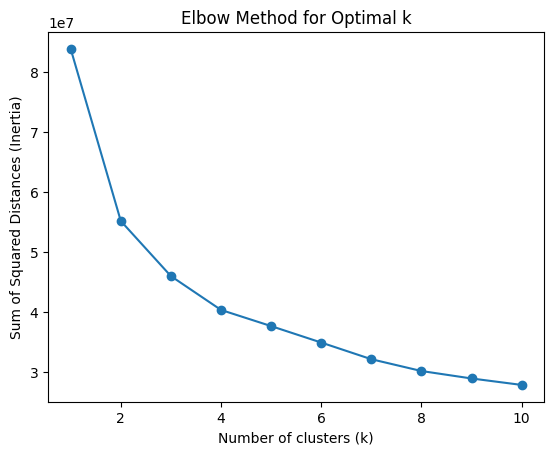

In [21]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select the standardized data (excluding the categorical column like LSOA21CD)
X = combined_df.drop(columns=['LSOA21CD'])

# List to hold the sum of squared distances for each k value
sse = []

# Try different numbers of clusters (for example, from 1 to 10)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    # Append the sum of squared distances (inertia)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.show()


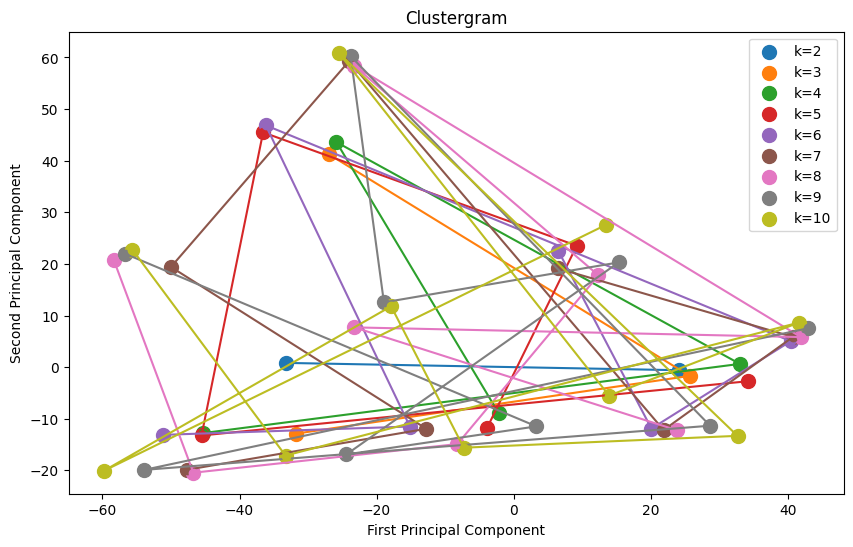

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Example data


# Function to create a clustergram
def plot_clustergram(X, max_k=10):
    pca = PCA(n_components=2)  # Reduce data to 2D using PCA for easier plotting
    reduced_data = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 6))
    
    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(reduced_data)
        centroids = kmeans.cluster_centers_
        
        # Plot cluster centers for each k
        plt.scatter(centroids[:, 0], centroids[:, 1], label=f'k={k}', s=100)
        plt.plot(centroids[:, 0], centroids[:, 1], '-o')
    
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Clustergram')
    plt.legend()
    plt.show()

# Call the function to plot the clustergram
plot_clustergram(X, max_k=10)


In [23]:
# Set the optimal number of clusters based on the elbow method (e.g., 4 clusters)
optimal_k = 7

# Initialize and fit the KMeans model with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
combined_df['Cluster'] = kmeans.fit_predict(X)

# Display the first few rows with the cluster assignments
print(combined_df[['LSOA21CD', 'Cluster']].head())


                      LSOA21CD  Cluster
0  E01011954 : Hartlepool 001A        1
1  E01011969 : Hartlepool 001B        5
2  E01011970 : Hartlepool 001C        5
3  E01011971 : Hartlepool 001D        5
4  E01033465 : Hartlepool 001F        5


In [24]:
# Skip the first row of the combined_df if it contains non-numeric data
# For further processing, ignore that row
numeric_columns = combined_df.iloc[1:].select_dtypes(include=['number']).columns

# Group by the 'Cluster' column and calculate the mean of each numeric variable in each cluster
cluster_summary = combined_df.iloc[1:].groupby('Cluster')[numeric_columns].mean()

# Display the summary of clusters
print(cluster_summary)


         %Conveniance  %Discounter  %Premium     %Value  %Online Often  \
Cluster                                                                  
0            6.576914     6.147567  2.257224  84.998670      12.891509   
1            6.792412     7.217456  1.622555  84.184864      19.398954   
2            6.327075     8.062331  1.437058  83.950025      22.761001   
3            6.656388     8.764048  1.112563  83.194662      22.973766   
4            6.776684     6.571702  1.757494  84.743624      17.273237   
5            6.622306     6.678726  2.102419  84.554941      14.945112   
6            6.794280     8.485908  1.112176  83.339085      21.464995   

         %Online Sometimes  %Online Rarely  %Online Never  %Less than £50  \
Cluster                                                                     
0                49.771841       28.246294       9.090356       22.199017   
1                52.530522       21.299401       6.771122       21.567260   
2                52.41362

In [26]:
pip install seaborn


   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ----- ---------------------------------- 41.0/294.9 kB 1.9 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\UTSM\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assuming you have a DataFrame `df` with your features and a 'Cluster' column representing the clusters
# Exclude the 'Cluster' and 'LSOA21CD' columns to calculate z-scores
features = df.drop(columns=['Cluster', 'LSOA21CD'])

# Calculate Z-scores
scaler = StandardScaler()
z_scores = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Add the Cluster labels back to the z-score DataFrame
z_scores['Cluster'] = df['Cluster']

# Calculate the mean z-scores for each cluster
cluster_means = z_scores.groupby('Cluster').mean()

# Transpose the DataFrame so that we can easily plot it
cluster_means_t = cluster_means.T



<Figure size 1000x600 with 0 Axes>

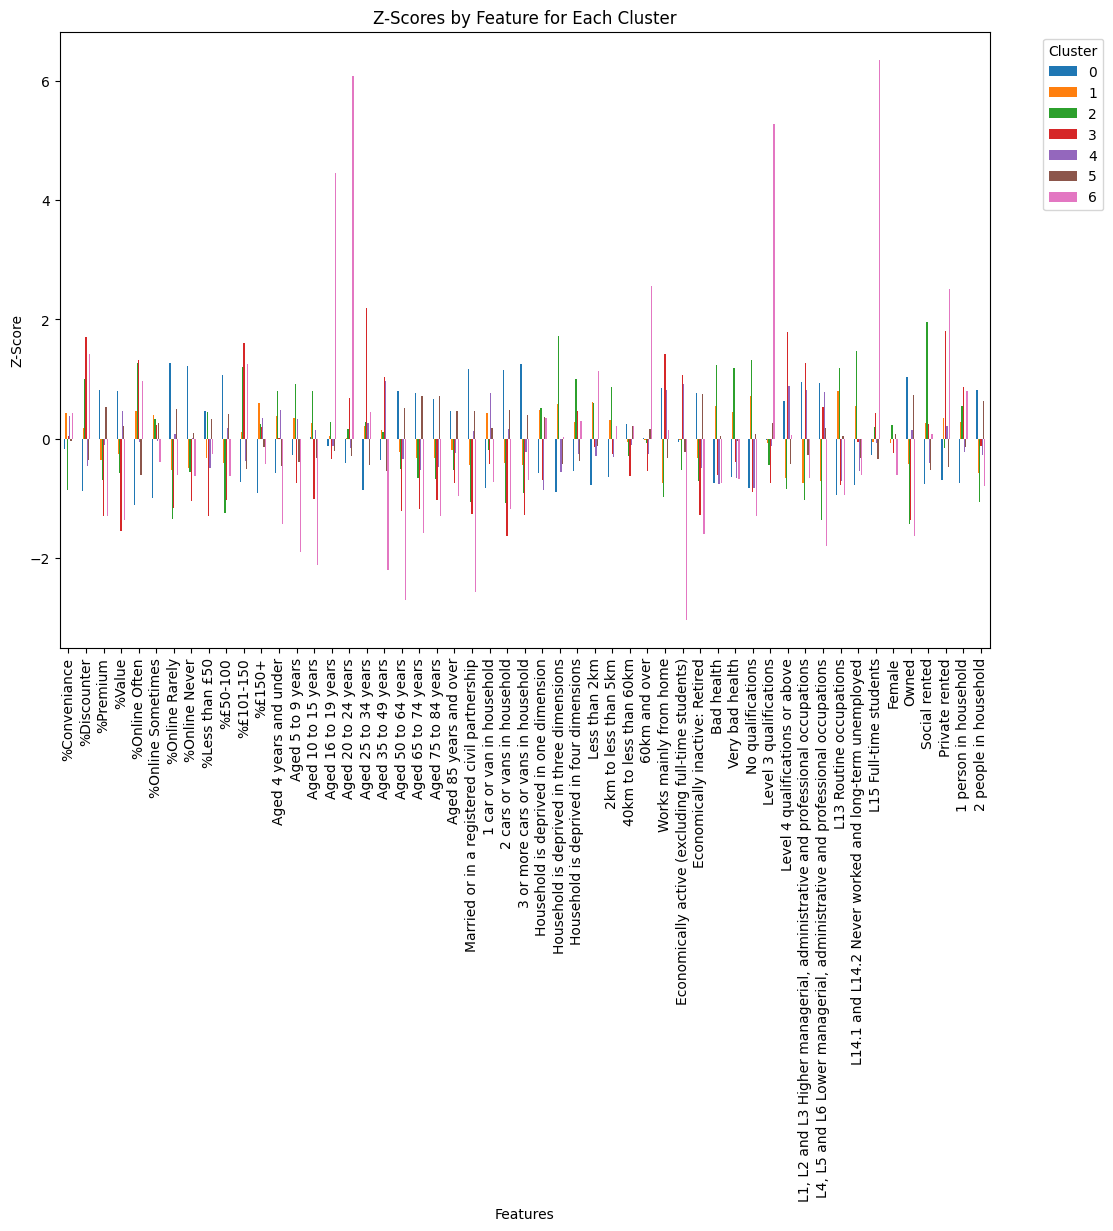

In [29]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot the z-scores for each cluster
cluster_means_t.plot(kind='bar', figsize=(12, 8))

plt.title('Z-Scores by Feature for Each Cluster')
plt.xlabel('Features')
plt.ylabel('Z-Score')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)

plt.show()



In [35]:
cluster_means_t


Cluster,0,1,2,3,4,5,6
%Conveniance,-0.165670,0.428730,-0.854798,0.053543,0.385355,-0.040465,0.433889
%Discounter,-0.875113,0.177831,1.009376,1.699998,-0.457684,-0.352352,1.426256
%Premium,0.817096,-0.350925,-0.692309,-1.289501,-0.102591,0.532199,-1.290212
%Value,0.793238,-0.263796,-0.568914,-1.550102,0.461942,0.216850,-1.362502
%Online Often,-1.111506,0.462491,1.275739,1.327203,-0.051648,-0.614778,0.962259
%Online Sometimes,-0.994531,0.389726,0.331007,0.226279,-0.044001,0.256925,-0.394167
%Online Rarely,1.272587,-0.524916,-1.338673,-1.168168,0.072101,0.494309,-0.605143
%Online Never,1.215872,-0.483555,-0.556986,-1.044243,0.016683,0.087513,-0.628032
%Less than £50,0.459710,-0.328748,0.450961,-1.293176,-0.486206,0.324740,-0.250230
%£50-100,1.070917,-0.410550,-1.242641,-1.025165,0.182036,0.409031,-0.619884


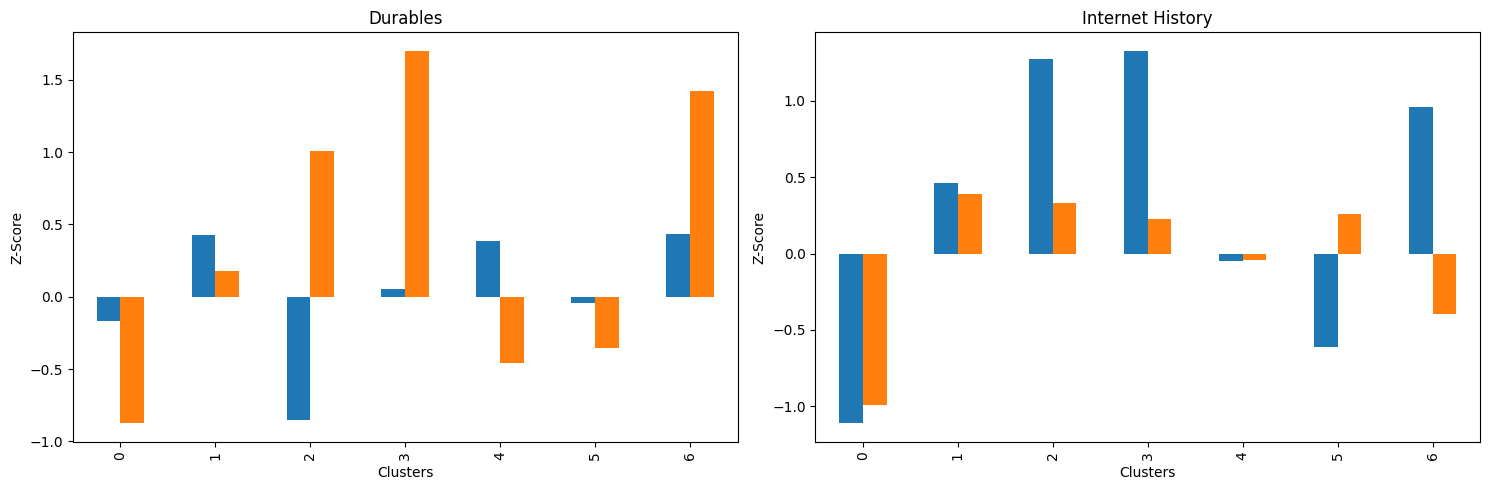

In [36]:
# Example: Grouped by different feature categories
feature_categories = {
    'Durables': ['%Conveniance', '%Discounter'],
    'Internet History': ['%Online Often', '%Online Sometimes'],
    # Add more categories and features accordingly
}

fig, axs = plt.subplots(nrows=1, ncols=len(feature_categories), figsize=(15, 5))

for ax, (category, feature_list) in zip(axs, feature_categories.items()):
    cluster_means[feature_list].plot(kind='bar', ax=ax, legend=False)
    ax.set_title(category)
    ax.set_xlabel('Clusters')
    ax.set_ylabel('Z-Score')

plt.tight_layout()
plt.show()


In [55]:
percentages_columns = percentages_df.columns[1:]  # Adjust this to your actual columns
total_columns = [col for col in combined_df.columns if col not in percentages_columns and col != 'LSOA21CD']

# Assign higher weights to the columns from 'percentages'
weight_factor = 20  # Adjust this to set the desired weight

# Apply the weight to the percentage columns
combined_df[percentages_columns] = combined_df[percentages_columns] * weight_factor

# Standardize the entire dataset (excluding 'LSOA21CD')
scaler = StandardScaler()
combined_df_standardized = combined_df.copy()  # Keep a copy of the original
combined_df_standardized[combined_df.columns[1:]] = scaler.fit_transform(combined_df[combined_df.columns[1:]])

# Now you can proceed with clustering
from sklearn.cluster import KMeans

# Determine the optimal number of clusters (k) using the elbow method
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(combined_df_standardized.iloc[:, 1:])  # Exclude 'LSOA21CD' during fitting

# Add the cluster labels back to the dataframe
combined_df_standardized['Cluster'] = kmeans.labels_

# Display the first few rows of the standardized data with clusters
print(combined_df_standardized.head())


                      LSOA21CD  %Conveniance  %Discounter  %Premium    %Value  \
0  E01011954 : Hartlepool 001A      0.379426    -0.049814 -0.339590  0.289182   
1  E01011969 : Hartlepool 001B     -0.523096    -0.333186  0.530934  0.473779   
2  E01011970 : Hartlepool 001C     -0.249266    -0.856139  0.687657  0.924416   
3  E01011971 : Hartlepool 001D      0.111652    -0.938483  1.217789  0.488952   
4  E01033465 : Hartlepool 001F      0.823945    -1.464932  0.540011  1.326723   

   %Online Often  %Online Sometimes  %Online Rarely  %Online Never  \
0       0.210199           0.909299       -0.409574      -0.804662   
1      -1.108645           1.513603        0.767782      -1.026002   
2      -1.278319          -0.299264        1.278758       0.688403   
3      -1.334460           0.408723        0.976428       0.680717   
4      -1.299496           0.344421        1.015248       0.558771   

   %Less than £50  ...  L13 Routine occupations  \
0       -0.788180  ...                 1.

In [58]:
output_file_path = '../data/combined_with_clusters1.csv'
cluster_summary.to_csv(output_file_path, index=False)
